> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Normality Check — histograms, Q-Q plots, Shapiro-Wilk / D'Agostino / Anderson-Darling
3. Data Preparation — Dates and Times are features and Close_next as target, train/test split **before** scaling, RobustScaler (fit on train only), sequence generation per split
4. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
5. Predict & Visualize
6. Evaluate — RMSE, MAE, MAPE

---
# 1. Fetching Stock Data

In [1]:
import yfinance as yf

stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
stock_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,14.894000,15.425333,14.600000,15.381333,102406500
2016-01-05,14.895333,15.126000,14.666667,15.090667,47802000
2016-01-06,14.602667,14.670000,14.398667,14.666667,56686500
2016-01-07,14.376667,14.562667,14.244667,14.279333,53314500
2016-01-08,14.066667,14.696000,14.051333,14.524000,54421500
...,...,...,...,...,...
2026-03-24,383.029999,387.480011,376.309998,376.559998,60004900
2026-03-25,385.950012,396.230011,385.010010,389.989990,55157300
2026-03-26,372.109985,384.440002,371.869995,381.600006,55522900


---
# 3. Data Preparation
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

## 3.1 Imports & Configuration

In [2]:
import numpy as np
from sklearn.preprocessing import RobustScaler

LOOKBACK = 60
TRAIN_RATIO = 0.8

stock_data['Close_nxt'] = stock_data['Close'].shift(-1)
stock_data = stock_data.dropna(subset=['Close_nxt'])

year_days = stock_data.index.is_leap_year * 366 + (1 - stock_data.index.is_leap_year.astype(int)) * 365
stock_data['sin_year'] = np.sin(2 * np.pi * (stock_data.index.dayofyear - 1) / year_days)
stock_data['cos_year'] = np.cos(2 * np.pi * (stock_data.index.dayofyear - 1) / year_days)

feature_cols = ['Close', 'sin_year','cos_year']
target_col = ['Close_nxt']

## 3.2 Train / Test Split (time-based, before scaling)

In [3]:
split_idx = int(len(stock_data) * TRAIN_RATIO)

train_features_raw = stock_data[feature_cols].values[:split_idx]
test_features_raw  = stock_data[feature_cols].values[split_idx:]

train_target_raw = stock_data[target_col].values[:split_idx]
test_target_raw  = stock_data[target_col].values[split_idx:]

print(f'Train samples : {len(train_features_raw)}')
print(f'Test  samples : {len(test_features_raw)}')

Train samples : 2058
Test  samples : 515


## 3.3 Feature Scaling — fit on train only

In [4]:
# Separate scalers so inverse_transform on the target works on 1 column
feature_scaler = RobustScaler()
target_scaler = RobustScaler()

train_features = feature_scaler.fit_transform(train_features_raw)
test_features  = feature_scaler.transform(test_features_raw)

train_target = target_scaler.fit_transform(train_target_raw)
test_target  = target_scaler.transform(test_target_raw)

print(f'Train features shape: {train_features.shape}')
print(f'Train target shape  : {train_target.shape}')

Train features shape: (2058, 3)
Train target shape  : (2058, 1)


## 3.4 Sequence Generation
Pad the test input with the last `LOOKBACK` rows from training so the first test sequence uses only train-era data.

In [5]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)


# Training sequences
X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)

# Test sequences — prepend last LOOKBACK rows from train to avoid boundary leakage
test_features_padded = np.concatenate([train_features[-LOOKBACK:], test_features])
test_target_padded = np.concatenate([train_target[-LOOKBACK:], test_target])
X_test, y_test = create_sequences(test_features_padded, test_target_padded, LOOKBACK)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1998, 60, 3)  y_train: (1998,)
X_test : (515, 60, 3)  y_test : (515,)


---
# 4. Building and Training LSTM

In [6]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,101 (476.96 KB)

 Trainable params: 122,101 (476.96 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - loss: 0.0337 - mae: 0.1018 - val_loss: 0.0090 - val_mae: 0.0746
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 265ms/step - loss: 0.0072 - mae: 0.0541 - val_loss: 0.0092 - val_mae: 0.0757
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - loss: 0.0071 - mae: 0.0521 - val_loss: 0.0080 - val_mae: 0.0711
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - loss: 0.0075 - mae: 0.0545 - val_loss: 0.0061 - val_mae: 0.0635
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0065 - mae: 0.0498 - val_loss: 0.0064 - val_mae: 0.0642
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - loss: 0.0062 - mae: 0.0493 - val_loss: 0.0067 - val_mae: 0.0655
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - loss: 0.0064 - mae: 0.0491 - val_loss: 0.0075 - val_mae: 0.0697
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0051 - mae: 0.0433 - val_loss: 0.0054 - val_mae: 0.0593
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s

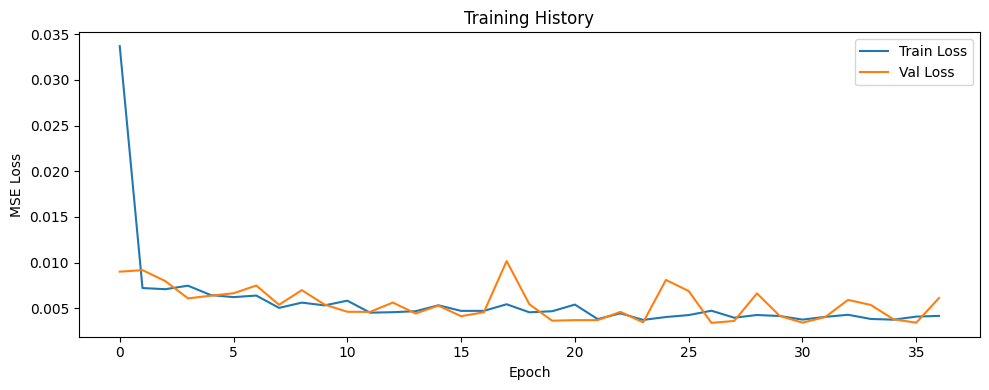

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 5. Making Predictions

In [9]:
pred_scaled = model.predict(X_test)

# Inverse-transform using the target scaler (fit on 1 column)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step


Predictions shape: (515, 1)
Actuals shape     : (515, 1)


---
# 6. Visualisation

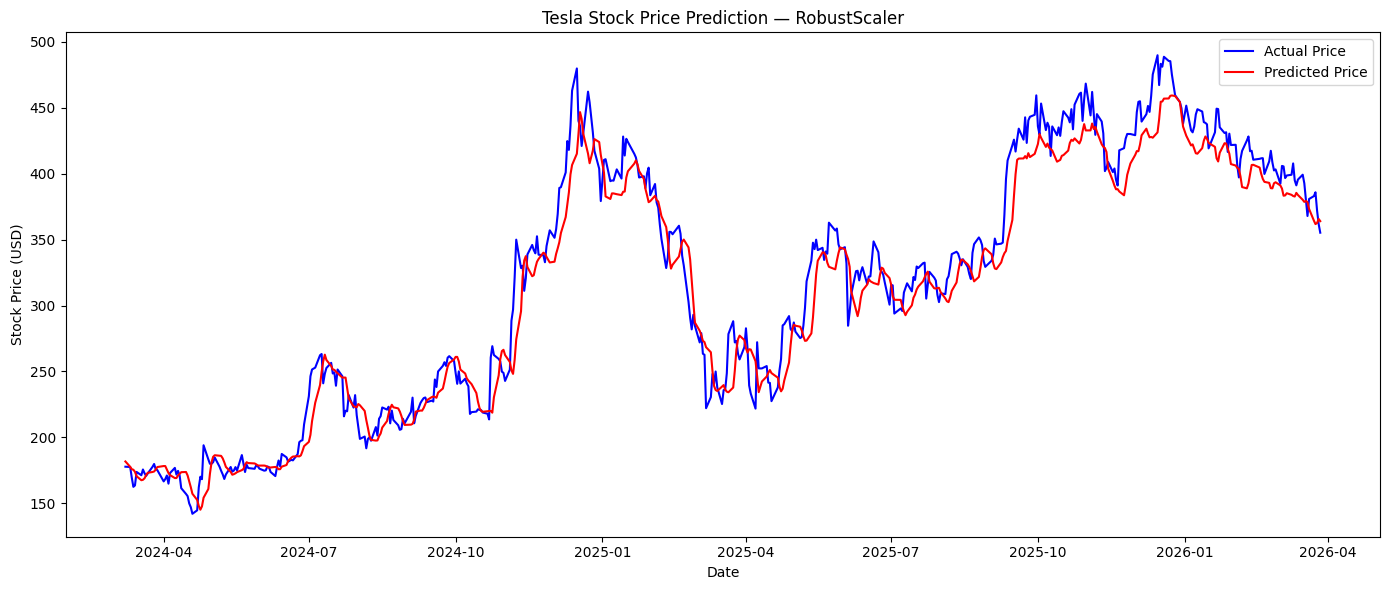

In [10]:
test_dates = stock_data.index[split_idx:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue')
plt.plot(test_dates, prediction.flatten(), label='Predicted Price', color='red')
plt.title('Tesla Stock Price Prediction — RobustScaler')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

---
# 7. Model Evaluation

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 45)
print('LSTM with RobustScaler — Test Metrics')
print('=' * 45)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 45)

LSTM with RobustScaler — Test Metrics
  MSE  : 418.3536
  RMSE : 20.4537
  MAE  : 15.5490
  MAPE : 4.91%


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


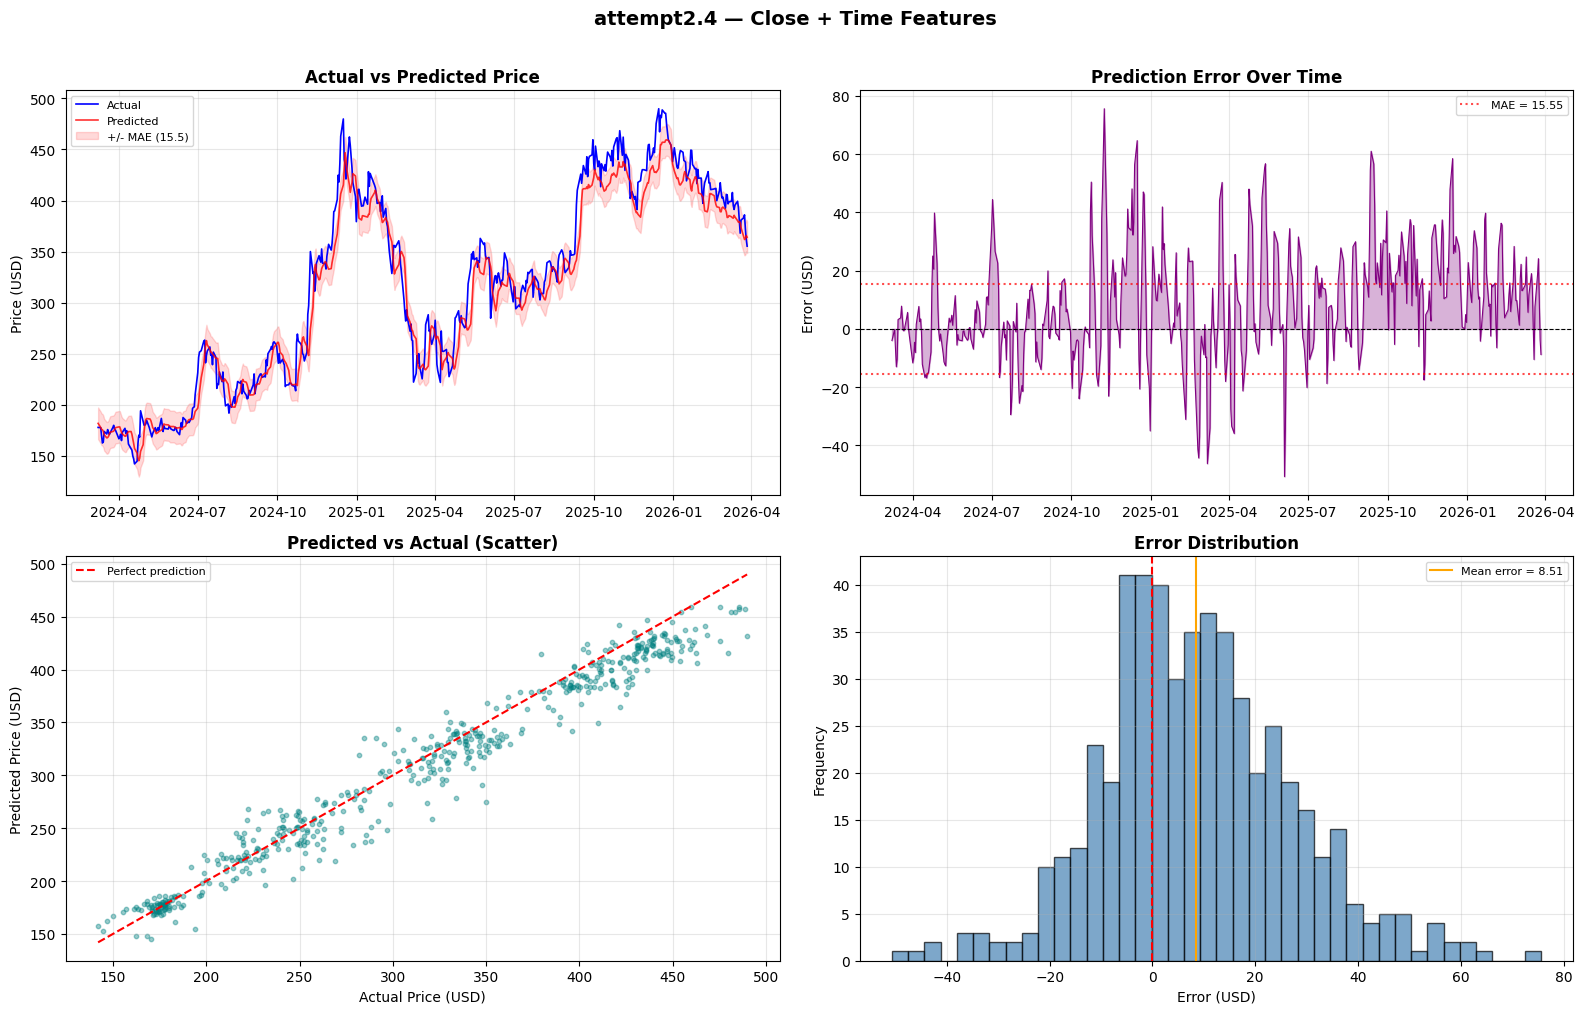

Mean Error: 8.5062  |  Std Error: 18.6010
Max Over-prediction: 75.6172  |  Max Under-prediction: -50.6985
Mean Abs % Error: 4.91%


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = stock_data.index[split_idx:]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('attempt2.4 — Close + Time Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')